<a href="https://colab.research.google.com/github/ridhoarte123/Tugas-_PCD/blob/main/Tugas_PCD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving WhatsApp Image 2026-03-30 at 11.20.49.jpeg to WhatsApp Image 2026-03-30 at 11.20.49.jpeg


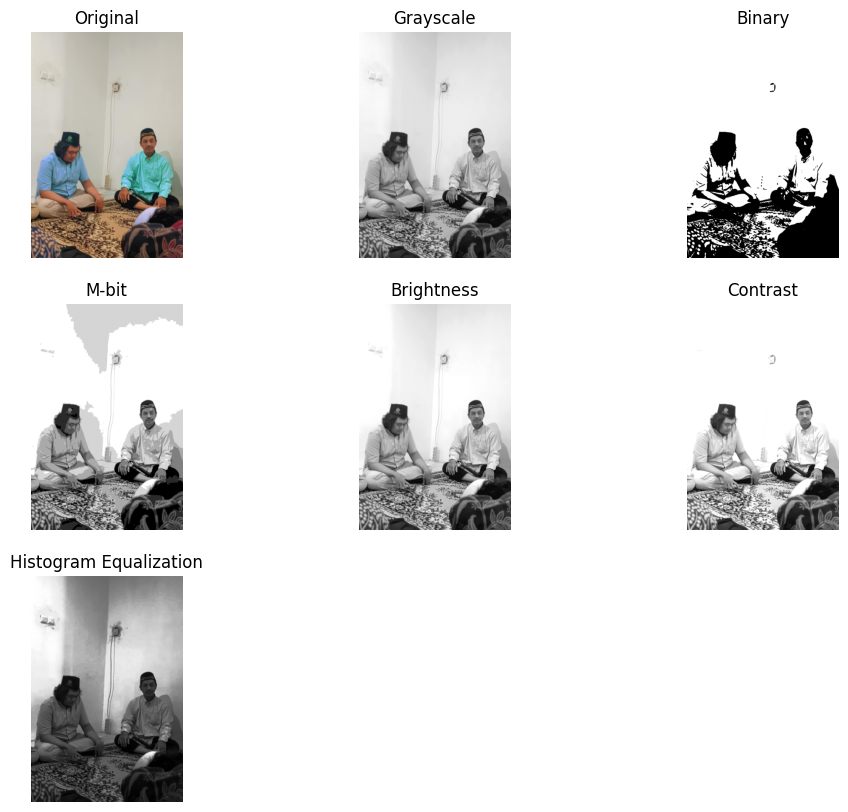

/tmp/ipykernel_6312/1070198206.py:90: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(gray.ravel(), 256, [0,256])


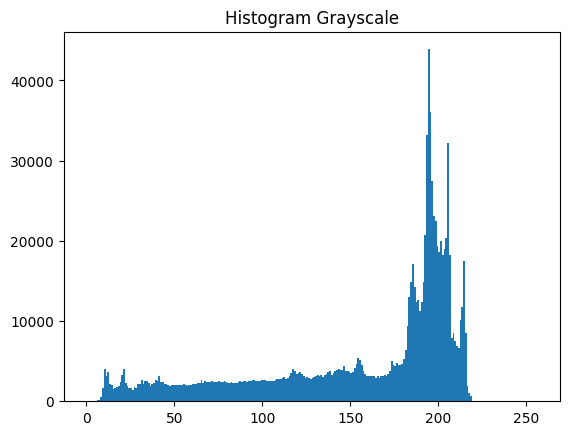

In [1]:
# ==============================
# IMPORT LIBRARY
# ==============================
import cv2
import numpy as np
from matplotlib import pyplot as plt
from google.colab import files

# ==============================
# UPLOAD FILE
# ==============================
uploaded = files.upload()

# Ambil nama file pertama
filename = list(uploaded.keys())[0]

# ==============================
# FUNCTION PROCESSING
# ==============================

def rgb_to_gray(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

def gray_to_binary(gray, threshold=128):
    _, binary = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    return binary

def gray_to_mbit(gray, levels=8):
    return (gray / 256 * levels).astype(np.uint8)

def adjust_brightness(gray, beta=50):
    return cv2.convertScaleAbs(gray, alpha=1, beta=beta)

def adjust_contrast(gray, alpha=1.5):
    return cv2.convertScaleAbs(gray, alpha=alpha, beta=0)

def histogram_equalization(gray):
    return cv2.equalizeHist(gray)

# ==============================
# MAIN PROGRAM
# ==============================

# Load image
img = cv2.imread(filename)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Proses pipeline
gray = rgb_to_gray(img)
binary = gray_to_binary(gray)
mbit = gray_to_mbit(gray)
bright = adjust_brightness(gray)
contrast = adjust_contrast(gray)
equalized = histogram_equalization(gray)

# ==============================
# VISUALISASI
# ==============================

titles = [
    'Original', 'Grayscale', 'Binary',
    'M-bit', 'Brightness', 'Contrast',
    'Histogram Equalization'
]

images = [
    img_rgb, gray, binary,
    mbit, bright, contrast,
    equalized
]

plt.figure(figsize=(12,10))

for i in range(len(images)):
    plt.subplot(3,3,i+1)

    if i == 0:
        plt.imshow(images[i])
    else:
        plt.imshow(images[i], cmap='gray')

    plt.title(titles[i])
    plt.axis('off')

plt.show()

# ==============================
# HISTOGRAM
# ==============================
plt.hist(gray.ravel(), 256, [0,256])
plt.title("Histogram Grayscale")
plt.show()